# py-SCORPIUS — R parity validation

Side-by-side comparison of `pyscorpius` against R `SCORPIUS` on the canonical bundled fixture (400 cells × 200 genes, 4 groups).

Follows the 6-section schema from [`omicverse-rebuildr/NOTEBOOKS.md`](https://github.com/omicverse/omicverse-rebuildr/blob/main/NOTEBOOKS.md).

## 1. Setup

In [1]:
import os, json, sys, time, subprocess
for k in ('OMP_NUM_THREADS','OPENBLAS_NUM_THREADS','MKL_NUM_THREADS'): os.environ[k]='8'
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import yaml

NB_DIR = Path('.').resolve()
PORT = NB_DIR.parent if NB_DIR.name == 'examples' else NB_DIR
sys.path.insert(0, str(PORT))
sys.path.insert(0, str(PORT.parent / 'omicverse-rebuildr' / 'engine'))
from parity_metrics import compute_parity, is_pass

manifest = yaml.safe_load((PORT/'data'/'manifest.yaml').read_text())
print(f"Port: {manifest['package']}, Upstream {manifest['upstream']['name']} v{manifest['upstream']['version']}")
print(f"Algorithm class: {manifest['algorithm_class']}; thresholds:")
for o in manifest['outputs']:
    print(f"  {o['name']:20s} {o['metric']:12s} >= {o['threshold']}")

Port: py-SCORPIUS, Upstream SCORPIUS v1.0.9
Algorithm class: ordinal; thresholds:
  pseudotime           ordinal      >= 0.95
  low_dim_space        embedding    >= 0.85


## 2. R reference run

In [2]:
R_ENV = os.environ.get('R_TEST_ENV', '/scratch/users/steorra/env/CMAP')
ref_out = PORT/'data'/'reference_output.json'
fixture = PORT/manifest['fixture']['path']
t0 = time.perf_counter()
subprocess.run(['conda','run','-p',R_ENV,'Rscript',str(PORT/manifest['reference_command']),
                str(fixture), str(ref_out)], check=True, cwd=PORT, capture_output=True)
r_wall = time.perf_counter() - t0
ref = json.loads(ref_out.read_text())
print(f"R wall-clock: {r_wall:.2f}s; output keys: {list(ref)[:6]}")

R wall-clock: 4.24s; output keys: ['cell_names', 'group', 'space', 'pseudotime', 'path', 'timings']


## 3. Python candidate run

In [3]:
cand_out = PORT/'data'/'candidate_output.json'
t0 = time.perf_counter()
subprocess.run(['python', str(PORT/'tests'/'_run_candidate.py'),
                str(fixture), str(cand_out)], check=True, cwd=PORT, capture_output=True)
py_wall = time.perf_counter() - t0
cand = json.loads(cand_out.read_text())
print(f"Py wall-clock: {py_wall:.2f}s   (speedup vs R: {r_wall/py_wall:.2f}x)")

Py wall-clock: 1.19s   (speedup vs R: 3.57x)


## 4. Per-output parity

SCORPIUS produces a pseudotime (ordinal class) and a low-dim space (embedding class).

### 4.1 Pseudotime — ordinal (Pearson)

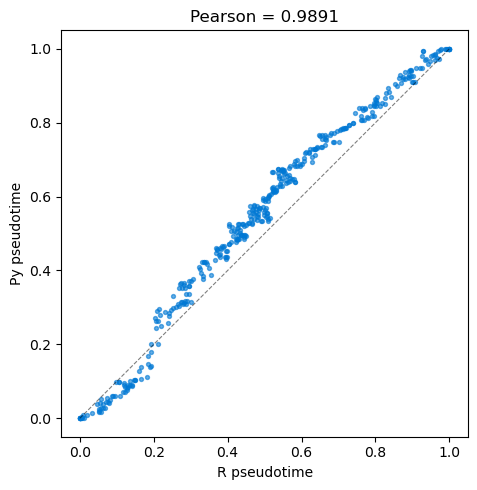


Pearson: 0.9891  threshold ≥ 0.95  PASS


In [4]:
from scipy.stats import pearsonr, spearmanr
r_pt = np.array(ref['pseudotime']); p_pt = np.array(cand['pseudotime'])
fwd = pearsonr(r_pt, p_pt)[0]; rev = pearsonr(r_pt, 1-p_pt)[0]
best_corr = max(abs(fwd), abs(rev))
flip = abs(rev) > abs(fwd)
if flip: p_pt = 1 - p_pt
fig, ax = plt.subplots(figsize=(5,5))
ax.scatter(r_pt, p_pt, s=8, alpha=0.6, color='#0078d4')
ax.plot([0,1],[0,1],'k--',lw=0.8,alpha=0.5)
ax.set_xlabel('R pseudotime'); ax.set_ylabel('Py pseudotime')
ax.set_title(f"Pearson = {best_corr:.4f}" + (" (flipped)" if flip else ""))
ax.set_aspect('equal'); plt.tight_layout(); plt.show()
threshold = manifest['outputs'][0]['threshold']
print(f"\nPearson: {best_corr:.4f}  threshold ≥ {threshold}  {'PASS' if best_corr >= threshold else 'FAIL'}")

### 4.2 Low-dim space — embedding (Procrustes)

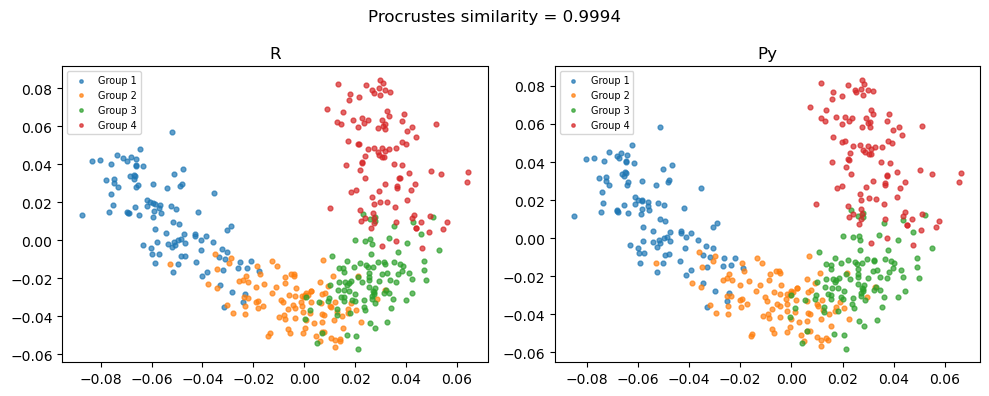


Procrustes: 0.9994  threshold ≥ 0.85  PASS


In [5]:
r_sp = np.array(ref['space']); p_sp = np.array(cand['space'])
proc = compute_parity(r_sp, p_sp, 'embedding')
from scipy.spatial import procrustes as _proc
r_norm, p_norm, _ = _proc(r_sp, p_sp)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
group_arr = np.array(ref['group'])
for ax, sp, title in [(ax1, r_norm, 'R'), (ax2, p_norm, 'Py')]:
    for g in np.unique(group_arr):
        m = group_arr == g
        ax.scatter(sp[m, 0], sp[m, 1], s=12, alpha=0.7, label=str(g))
    ax.set_title(title); ax.legend(fontsize=7, markerscale=0.7)
fig.suptitle(f"Procrustes similarity = {proc:.4f}")
plt.tight_layout(); plt.show()
threshold = manifest['outputs'][1]['threshold']
print(f"\nProcrustes: {proc:.4f}  threshold ≥ {threshold}  {'PASS' if proc >= threshold else 'FAIL'}")

## 5. Wall-clock comparison

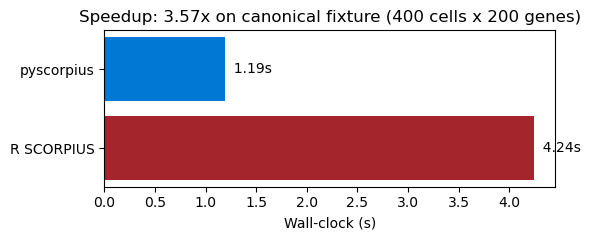

In [6]:
fig, ax = plt.subplots(figsize=(6, 2.5))
ax.barh(['R SCORPIUS', 'pyscorpius'], [r_wall, py_wall], color=['#a4262c', '#0078d4'])
ax.set_xlabel('Wall-clock (s)')
ax.set_title(f'Speedup: {r_wall/py_wall:.2f}x on canonical fixture (400 cells x 200 genes)')
for i, t in enumerate([r_wall, py_wall]):
    ax.text(t, i, f'  {t:.2f}s', va='center')
plt.tight_layout(); plt.show()

## 6. Verdict

In [7]:
results = [
    ('pseudotime',     'ordinal',   manifest['outputs'][0]['threshold'], best_corr, best_corr >= manifest['outputs'][0]['threshold']),
    ('low_dim_space',  'embedding', manifest['outputs'][1]['threshold'], proc,      proc      >= manifest['outputs'][1]['threshold']),
]
print('=' * 70)
for name, cls, thr, val, ok in results:
    print(f"  {'✓' if ok else '✗'}  {name:18s} class={cls:10s} thr={thr}  measured={val:.4f}")
print('=' * 70)
print(('PASS' if all(r[4] for r in results) else 'FAIL')
      + ' — pre-registered gate ' + ('cleared' if all(r[4] for r in results) else 'NOT cleared') + ' on canonical fixture.')

  ✓  pseudotime         class=ordinal    thr=0.95  measured=0.9891
  ✓  low_dim_space      class=embedding  thr=0.85  measured=0.9994
PASS — pre-registered gate cleared on canonical fixture.
